**Laboratório Computacional para Precificação de Opções via Modelo Binomial**



**Parte 01 - CRR + Convergência**

In [1]:
#Bloco 1 - Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
#Bloco 2 — Função CRR

def binomial_crr(S0, K, r, sigma, T, N, option_type="call", american=False):
    """
    Precificação de opções pelo modelo binomial de Cox-Ross-Rubinstein (CRR).

    Parâmetros:
    S0 : preço inicial do ativo
    K : preço de exercício
    r : taxa livre de risco anual
    sigma : volatilidade anual
    T : tempo até o vencimento, em anos
    N : número de passos da árvore
    option_type : "call" ou "put"
    american : True para opção americana, False para europeia

    Retorna:
    preço da opção no tempo inicial
    """

    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    disc = np.exp(-r * dt)

    p = (np.exp(r * dt) - d) / (u - d)

    if not (0 < p < 1):
        raise ValueError("Probabilidade neutra ao risco fora do intervalo (0,1).")

    # preços do ativo no vencimento
    j = np.arange(N + 1)
    S_T = S0 * (u ** j) * (d ** (N - j))

    # payoff no vencimento
    if option_type == "call":
        V = np.maximum(S_T - K, 0)
    elif option_type == "put":
        V = np.maximum(K - S_T, 0)
    else:
        raise ValueError("option_type deve ser 'call' ou 'put'.")

    # indução reversa
    for n in range(N - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])

        if american:
            j = np.arange(n + 1)
            S_n = S0 * (u ** j) * (d ** (n - j))

            if option_type == "call":
                exercise = np.maximum(S_n - K, 0)
            else:
                exercise = np.maximum(K - S_n, 0)

            V = np.maximum(V, exercise)

    return V[0]

In [3]:
#Bloco 3 — Validação simples
#Esse bloco é só para testar se a função roda. Depois faremos uma validação mais adequada com parâmetros clássicos.

S0 = 3
K = 3
r = np.log(4/3)   # equivalente contínuo aproximado para 1 + r_discreto = 4/3
sigma = 0.3
T = 1
N = 1

preco = binomial_crr(S0, K, r, sigma, T, N, option_type="call", american=False)
preco

np.float64(0.7658232132612095)

In [4]:
#Bloco 4 — Experimento 1: convergência com N

S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

valores_N = [5, 10, 20, 40, 80, 160, 320, 640, 1000]

resultados = []

for N in valores_N:
    inicio = time.time()
    preco = binomial_crr(S0, K, r, sigma, T, N, option_type="call", american=False)
    tempo = time.time() - inicio

    resultados.append({
        "N": N,
        "Preço CRR": preco,
        "Tempo (s)": tempo
    })

df_convergencia = pd.DataFrame(resultados)
df_convergencia["Diferença"] = df_convergencia["Preço CRR"].diff().abs()

df_convergencia

,N,Preço CRR,Tempo (s),Diferença
0,5,10.805934,0.000160,NaN
1,10,10.253409,0.000106,0.552525
2,20,10.351260,0.000135,0.097851
3,40,10.400751,0.000392,0.049491
4,80,10.425627,0.001603,0.024875
5,160,10.438095,0.001209,0.012468
6,320,10.444337,0.001992,0.006242
7,640,10.447460,0.008303,0.003123
8,1000,10.448584,0.009674,0.001124


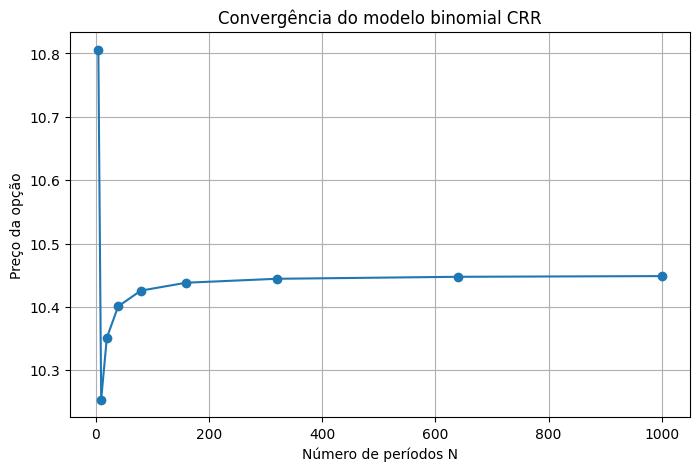

In [5]:
#Bloco 5 — Gráfico de convergência

plt.figure(figsize=(8,5))
plt.plot(df_convergencia["N"], df_convergencia["Preço CRR"], marker="o")
plt.xlabel("Número de períodos N")
plt.ylabel("Preço da opção")
plt.title("Convergência do modelo binomial CRR")
plt.grid(True)
plt.show()

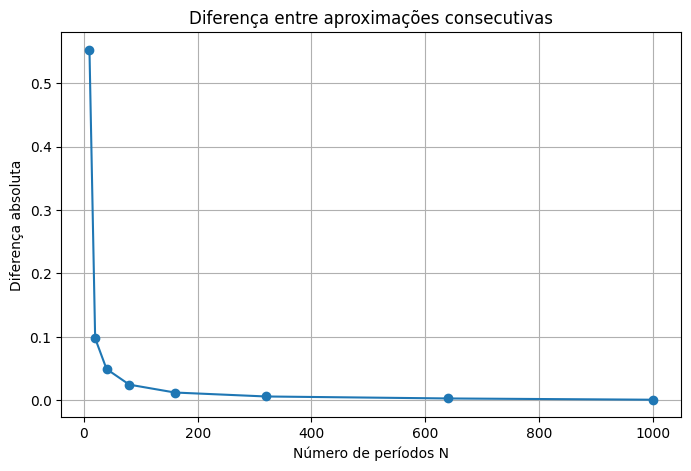

In [6]:
#Bloco 6 — Diferença entre aproximações sucessivas

plt.figure(figsize=(8,5))
plt.plot(df_convergencia["N"], df_convergencia["Diferença"], marker="o")
plt.xlabel("Número de períodos N")
plt.ylabel("Diferença absoluta")
plt.title("Diferença entre aproximações consecutivas")
plt.grid(True)
plt.show()

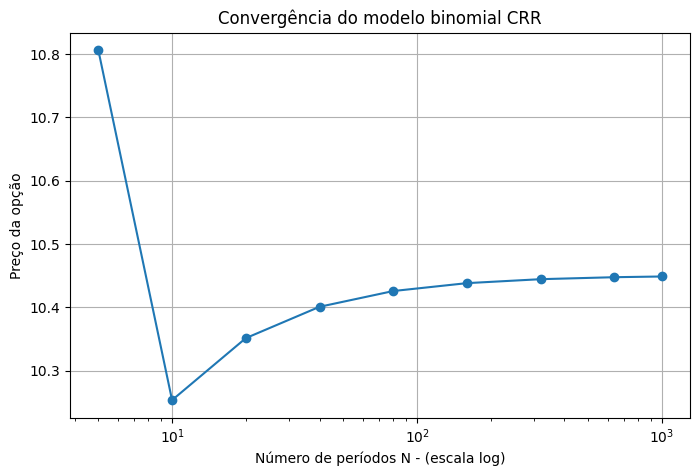

In [7]:
#Bloco 7 - diferença absoluta entre aproximações consecutivas na sequência de valores
# escala logarítmica no eixo N
plt.figure(figsize=(8,5))
plt.plot(df_convergencia["N"], df_convergencia["Preço CRR"], marker="o")
plt.xscale("log")
plt.xlabel("Número de períodos N - (escala log)")
plt.ylabel("Preço da opção")
plt.title("Convergência do modelo binomial CRR")
plt.grid(True)
plt.show()

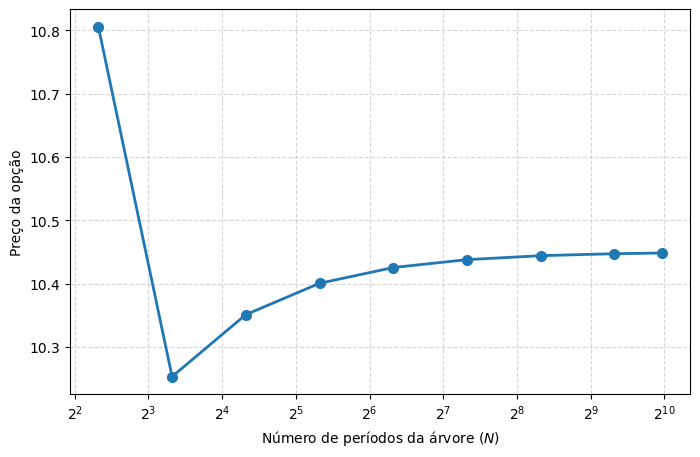

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    df_convergencia["N"],
    df_convergencia["Preço CRR"],
    marker="o",
    linewidth=2,
    markersize=7
)

plt.xscale("log", base=2)

plt.xlabel("Número de períodos da árvore ($N$)")
plt.ylabel("Preço da opção")

#plt.title("Convergência do modelo binomial CRR")

plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.savefig("convergencia_crr.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Parte 2 - Método JR**

In [9]:

def binomial_jr(S0, K, r, sigma, T, N, option_type="call", american=False):
    """
    Precificação de opções pelo modelo binomial de Jarrow-Rudd (JR).

    Parâmetros:
    S0 : preço inicial do ativo
    K : preço de exercício
    r : taxa livre de risco anual (capitalização contínua)
    sigma : volatilidade anual
    T : tempo até o vencimento (anos)
    N : número de passos da árvore
    option_type : "call" ou "put"
    american : True para opção americana, False para europeia

    Retorna:
    preço da opção no tempo inicial
    """

    import numpy as np

    dt = T / N

    # Parâmetros de Jarrow-Rudd
    u = np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt))
    d = np.exp((r - 0.5 * sigma**2) * dt - sigma * np.sqrt(dt))
    p = 0.5

    disc = np.exp(-r * dt)

    # Preços do ativo no vencimento
    j = np.arange(N + 1)
    S_T = S0 * (u**j) * (d**(N - j))

    # Payoff
    if option_type == "call":
        V = np.maximum(S_T - K, 0)
    elif option_type == "put":
        V = np.maximum(K - S_T, 0)
    else:
        raise ValueError("option_type deve ser 'call' ou 'put'.")

    # Indução reversa
    for n in range(N - 1, -1, -1):

        V = disc * (p * V[1:] + (1 - p) * V[:-1])

        if american:

            j = np.arange(n + 1)

            S_n = S0 * (u**j) * (d**(n - j))

            if option_type == "call":
                exercise = np.maximum(S_n - K, 0)
            else:
                exercise = np.maximum(K - S_n, 0)

            V = np.maximum(V, exercise)

    return V[0]

In [10]:
resultados_jr = []

for N in valores_N:

    preco = binomial_jr(
        S0,
        K,
        r,
        sigma,
        T,
        N,
        option_type="call",
        american=False
    )

    resultados_jr.append({
        "N": N,
        "Preço JR": preco
    })

df_jr = pd.DataFrame(resultados_jr)

df_jr

,N,Preço JR
0,5,10.755683
1,10,10.524834
2,20,10.520922
3,40,10.496529
4,80,10.468485
5,160,10.443302
6,320,10.455151
7,640,10.449778
8,1000,10.452179


In [11]:
df = pd.merge(df_convergencia, df_jr, on="N")

df

,N,Preço CRR,Tempo (s),Diferença,Preço JR
0,5,10.805934,0.000160,NaN,10.755683
1,10,10.253409,0.000106,0.552525,10.524834
2,20,10.351260,0.000135,0.097851,10.520922
3,40,10.400751,0.000392,0.049491,10.496529
4,80,10.425627,0.001603,0.024875,10.468485
5,160,10.438095,0.001209,0.012468,10.443302
6,320,10.444337,0.001992,0.006242,10.455151
7,640,10.447460,0.008303,0.003123,10.449778
8,1000,10.448584,0.009674,0.001124,10.452179


In [12]:
df["Diferença CRR-JR"] = abs(df["Preço CRR"] - df["Preço JR"])

df

,N,Preço CRR,Tempo (s),Diferença,Preço JR,Diferença CRR-JR
0,5,10.805934,0.000160,NaN,10.755683,0.050251
1,10,10.253409,0.000106,0.552525,10.524834,0.271425
2,20,10.351260,0.000135,0.097851,10.520922,0.169662
3,40,10.400751,0.000392,0.049491,10.496529,0.095778
4,80,10.425627,0.001603,0.024875,10.468485,0.042858
5,160,10.438095,0.001209,0.012468,10.443302,0.005207
6,320,10.444337,0.001992,0.006242,10.455151,0.010814
7,640,10.447460,0.008303,0.003123,10.449778,0.002319
8,1000,10.448584,0.009674,0.001124,10.452179,0.003595


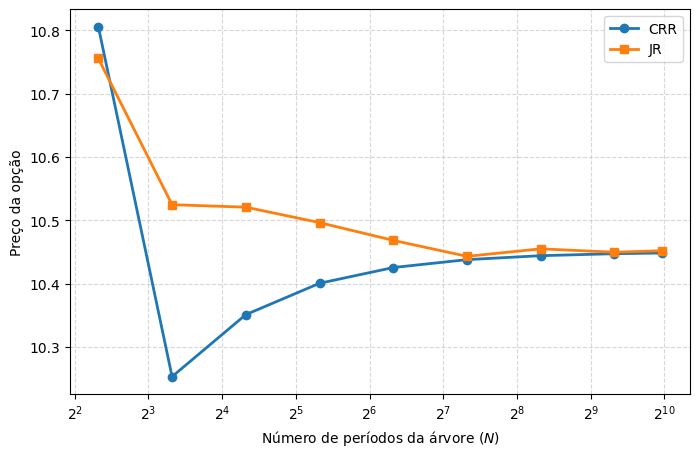

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    df["N"],
    df["Preço CRR"],
    marker="o",
    linewidth=2,
    label="CRR"
)

plt.plot(
    df["N"],
    df["Preço JR"],
    marker="s",
    linewidth=2,
    label="JR"
)

plt.xscale("log", base=2)

plt.xlabel("Número de períodos da árvore ($N$)")
plt.ylabel("Preço da opção")

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.savefig(
    "comparacao_crr_jr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Parte 3 - Método de Monte Carlo**

In [14]:
def monte_carlo_binomial_crr(S0, K, r, sigma, T, N, M, option_type="call", seed=123):
    """
    Monte Carlo aplicado diretamente à árvore binomial CRR.

    S0 : preço inicial do ativo
    K : preço de exercício
    r : taxa livre de risco anual
    sigma : volatilidade anual
    T : vencimento em anos
    N : número de períodos da árvore
    M : número de caminhos simulados
    option_type : "call" ou "put"
    seed : semente aleatória
    """

    rng = np.random.default_rng(seed)

    dt = T / N

    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    p = (np.exp(r * dt) - d) / (u - d)

    if not (0 < p < 1):
        raise ValueError("Probabilidade neutra ao risco fora do intervalo (0,1).")

    # Gera M caminhos com N movimentos: True = subida, False = descida
    movimentos = rng.random((M, N)) < p

    # Número de subidas em cada caminho
    num_subidas = movimentos.sum(axis=1)

    # Número de descidas em cada caminho
    num_descidas = N - num_subidas

    # Preço final em cada caminho
    S_T = S0 * (u ** num_subidas) * (d ** num_descidas)

    # Payoff
    if option_type == "call":
        payoff = np.maximum(S_T - K, 0)
    elif option_type == "put":
        payoff = np.maximum(K - S_T, 0)
    else:
        raise ValueError("option_type deve ser 'call' ou 'put'.")

    # Valor presente esperado
    preco = np.exp(-r * T) * payoff.mean()

    return preco

In [15]:
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

N = 100
valores_M = [100, 500, 1000, 5000, 10000, 50000, 100000]

# valor de referência usando CRR determinístico
preco_ref = binomial_crr(S0, K, r, sigma, T, N, option_type="call", american=False)

resultados_mc = []

for M in valores_M:
    preco_mc = monte_carlo_binomial_crr(
        S0, K, r, sigma, T, N, M,
        option_type="call",
        seed=123
    )

    resultados_mc.append({
        "M": M,
        "Preço MC": preco_mc,
        "Valor de referência (CRR)": preco_ref,
        "Erro absoluto": abs(preco_mc - preco_ref)
    })

df_mc = pd.DataFrame(resultados_mc)
df_mc

,M,Preço MC,Valor de referência (CRR),Erro absoluto
0,100,12.337659,10.430612,1.907047
1,500,11.616093,10.430612,1.185482
2,1000,10.842953,10.430612,0.412341
3,5000,10.609512,10.430612,0.178901
4,10000,10.482372,10.430612,0.051760
5,50000,10.397039,10.430612,0.033573
6,100000,10.439945,10.430612,0.009333


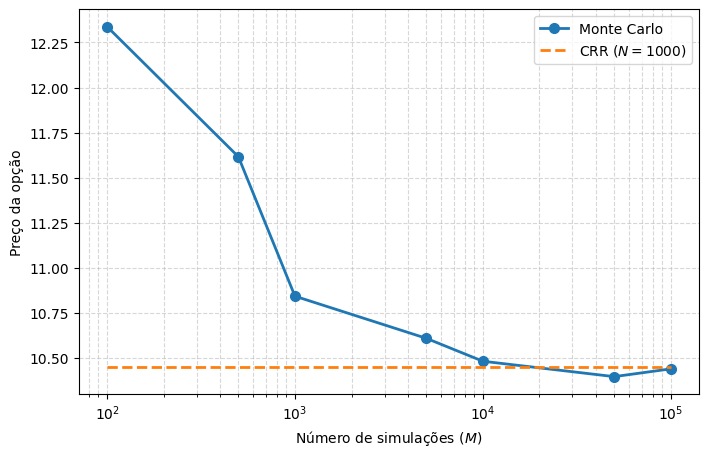

In [16]:
# Valor de referência pelo método CRR com N = 1000
preco_ref = binomial_crr(
    S0, K, r, sigma, T,
    N=1000,
    option_type="call",
    american=False
)

plt.figure(figsize=(8,5))

# Estimativas de Monte Carlo
plt.plot(
    df_mc["M"],
    df_mc["Preço MC"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="Monte Carlo"
)

# Valor de referência CRR
plt.plot(
    df_mc["M"],
    [preco_ref] * len(df_mc),
    linestyle="--",
    linewidth=2,
    label="CRR ($N=1000$)"
)

plt.xscale("log", base=10)

plt.xlabel("Número de simulações ($M$)")
plt.ylabel("Preço da opção")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.savefig(
    "monte_carlo_binomial.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
preco_ref = binomial_crr(S0, K, r, sigma, T, 1000, option_type="call", american=False)

df_mc["Valor de referência (CRR)"] = preco_ref
df_mc["Erro absoluto"] = abs(df_mc["Preço MC"] - preco_ref)

df_mc

,M,Preço MC,Valor de referência (CRR),Erro absoluto
0,100,12.337659,10.448584,1.889075
1,500,11.616093,10.448584,1.167509
2,1000,10.842953,10.448584,0.394369
3,5000,10.609512,10.448584,0.160928
4,10000,10.482372,10.448584,0.033788
5,50000,10.397039,10.448584,0.051546
6,100000,10.439945,10.448584,0.008639


**Parte 4 - Simulação com Dados Reais**

T: tempo entre 30/06/2026 e 14/08/2026;

r: taxa livre de risco;

σhist : volatilidade histórica da PETR4;

preços por CRR, JR e Monte Carlo usando:

volatilidade histórica;

volatilidade implícita.

In [18]:
S0_real = 37.80
K_real = 38.36
premio_mercado = 1.63
sigma_implicita = 0.2675

In [19]:
from datetime import datetime

data_coleta = datetime(2026, 6, 30)
data_vencimento = datetime(2026, 8, 14)

dias_corridos = (data_vencimento - data_coleta).days
T_real = dias_corridos / 365

dias_corridos, T_real

(45, 0.1232876712328767)

In [20]:
S0_real = 37.80
K_real = 38.36
premio_mercado = 1.63

sigma_implicita = 0.2675
r_real = 0.15   # por enquanto; depois podemos trocar por Selic/CDI

N_real = 1000
M_real = 100000

In [21]:
crr_imp = binomial_crr(S0_real, K_real, r_real, sigma_implicita, T_real, N_real)
jr_imp = binomial_jr(S0_real, K_real, r_real, sigma_implicita, T_real, N_real)
mc_imp = monte_carlo_binomial_crr(S0_real, K_real, r_real, sigma_implicita,
                                  T_real, N=100, M=M_real, seed=123)

crr_imp, jr_imp, mc_imp

(np.float64(1.486115957816438),
 np.float64(1.4857003523212697),
 np.float64(1.4884178210935914))

In [22]:
#baixar a série da PETR4 até 30/06/2026, calcular os retornos logarítmicos e anualizar a volatilidade.
import yfinance as yf
import numpy as np

ticker = "PETR4.SA"

dados = yf.download(
    ticker,
    start="2025-06-30",
    end="2026-07-01",
    auto_adjust=False
)

precos = dados["Close"].squeeze().dropna()

retornos_log = np.log(precos / precos.shift(1)).dropna()

sigma_historica = retornos_log.std() * np.sqrt(252)

print(f" Volatilidade histórica: {sigma_historica:.4%}")

[*********************100%***********************]  1 of 1 completed

 Volatilidade histórica: 24.8948%


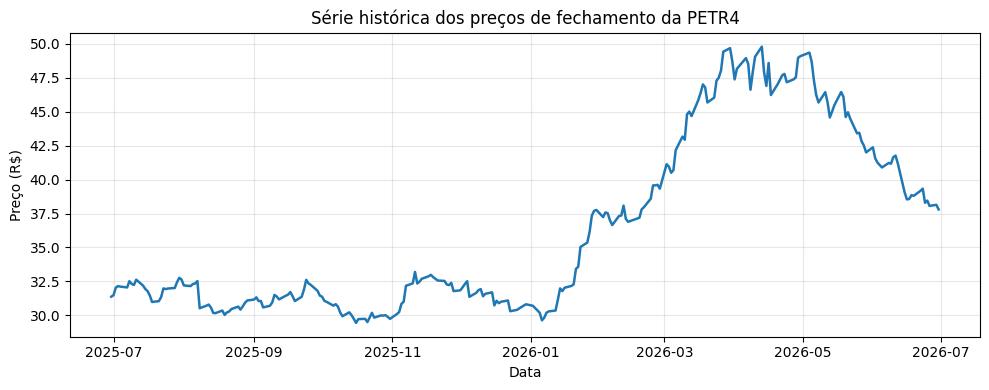

In [34]:
#Gráfico da série histórica dos preços da ação PETR4

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(precos.index, precos, linewidth=1.8)
plt.title("Série histórica dos preços de fechamento da PETR4")
plt.xlabel("Data")
plt.ylabel("Preço (R$)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

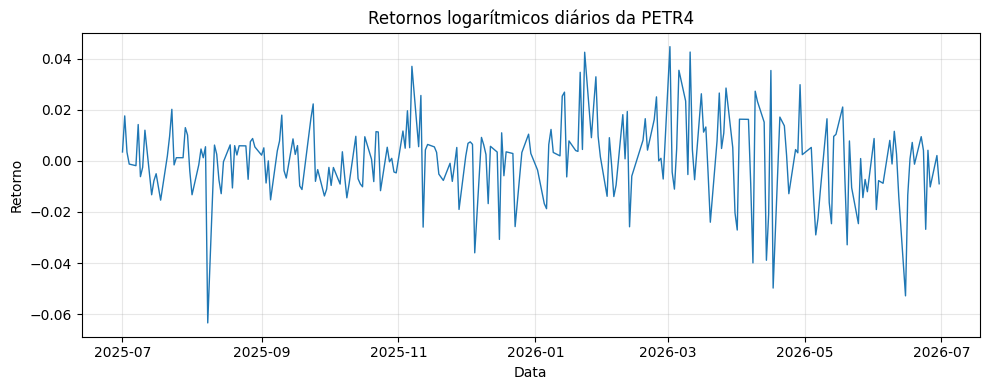

In [28]:
plt.figure(figsize=(10,4))
plt.plot(retornos_log.index, retornos_log, linewidth=1)
plt.title("Retornos logarítmicos diários da PETR4")
plt.xlabel("Data")
plt.ylabel("Retorno")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

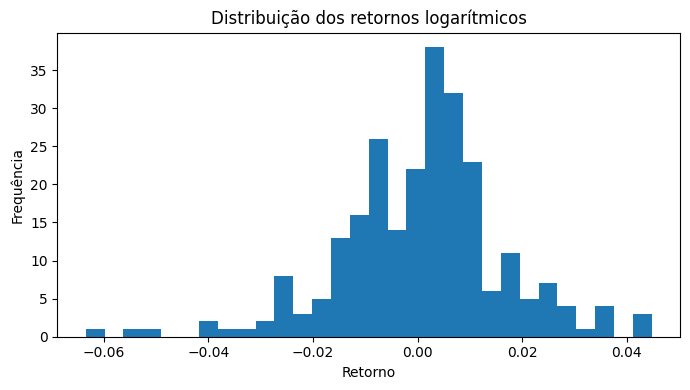

In [29]:
plt.figure(figsize=(7,4))
plt.hist(retornos_log, bins=30)
plt.title("Distribuição dos retornos logarítmicos")
plt.xlabel("Retorno")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

In [31]:
print(f"Volatilidade histórica anual: {sigma_historica:.4%}")
print(f"Número de pregões: {len(precos)}")
print(f"Período: {precos.index[0].date()} até {precos.index[-1].date()}")

Volatilidade histórica anual: 24.8948%
Número de pregões: 251
Período: 2025-06-30 até 2026-06-30


In [24]:
crr_hist = binomial_crr(
    S0_real, K_real, r_real, sigma_historica, T_real, N_real
)

jr_hist = binomial_jr(
    S0_real, K_real, r_real, sigma_historica, T_real, N_real
)

mc_hist = monte_carlo_binomial_crr(
    S0_real, K_real, r_real, sigma_historica,
    T_real, N=100, M=M_real, seed=123
)

crr_hist, jr_hist, mc_hist

(np.float64(1.3881659163774436),
 np.float64(1.3876174718122538),
 np.float64(1.3891898883136324))

In [25]:
mercado = 1.63

df_real = pd.DataFrame({
    "Método": ["CRR", "JR", "Monte Carlo"],
    "Vol. histórica": [crr_hist, jr_hist, mc_hist],
    "Vol. implícita": [crr_imp, jr_imp, mc_imp]
})

df_real["Erro hist. (%)"] = 100 * abs(df_real["Vol. histórica"] - mercado) / mercado
df_real["Erro impl. (%)"] = 100 * abs(df_real["Vol. implícita"] - mercado) / mercado

df_real

,Método,Vol. histórica,Vol. implícita,Erro hist. (%),Erro impl. (%)
0,CRR,1.388166,1.486116,14.836447,8.827242
1,JR,1.387617,1.485700,14.870094,8.852739
2,Monte Carlo,1.389190,1.488418,14.773626,8.686023


In [27]:
n = len(retornos_log)
print(n)

250
